<a href="https://colab.research.google.com/github/sumitchhipa/python-learning/blob/main/practice_supervised_ml_day_1_and_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [67]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder


In [68]:
df=pd.read_csv("/content/covid_toy.csv")

In [69]:
df.head()

,age,gender,fever,cough,city,has_covid
0,60,Male,103.0,Mild,Kolkata,No
1,27,Male,100.0,Mild,Delhi,Yes
2,42,Male,101.0,Mild,Delhi,No
3,31,Female,98.0,Mild,Kolkata,No
4,65,Female,101.0,Mild,Mumbai,No


In [70]:
df.isnull().sum()

,0
age,0
gender,0
fever,10
cough,0
city,0
has_covid,0


In [71]:
df['fever'] = df['fever'].fillna(df['fever'].mean())

In [72]:
df.isnull().sum()

,0
age,0
gender,0
fever,0
cough,0
city,0
has_covid,0


In [73]:

le = LabelEncoder()
df['city'] = le.fit_transform(df['city'])
df['gender'] = le.fit_transform(df['gender'])
df['cough'] = le.fit_transform(df['cough'])
df['has_covid'] = le.fit_transform(df['has_covid'])

In [74]:
df.head()

,age,gender,fever,cough,city,has_covid
0,60,1,103.0,0,2,0
1,27,1,100.0,0,1,1
2,42,1,101.0,0,1,0
3,31,0,98.0,0,2,0
4,65,0,101.0,0,3,0


In [75]:
X=df.drop('has_covid',axis=1)
y=df['has_covid']

In [76]:
x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)


In [77]:
lr=LogisticRegression()
lr.fit(x_train,y_train)

LogisticRegression()

In [78]:
#y_pred=lr.predict(x_test)

In [79]:
# accuracy=lr.score(x_test,y_test)
# accuracy

In [80]:
from sklearn.tree import DecisionTreeClassifier

In [81]:
# dtc=DecisionTreeClassifier()
# dtc.fit(x_train,y_train)

In [82]:
# y_pred=dtc.predict(x_test)
# accuracy=dtc.score(x_test,y_test)
# accuracy

In [83]:
from sklearn.ensemble import RandomForestClassifier


In [84]:
rfc=RandomForestClassifier()
rfc.fit(x_train,y_train)

RandomForestClassifier()

In [85]:
y_pred = rfc.predict(x_test)
accuracy = rfc.score(x_test, y_test)
accuracy

0.55

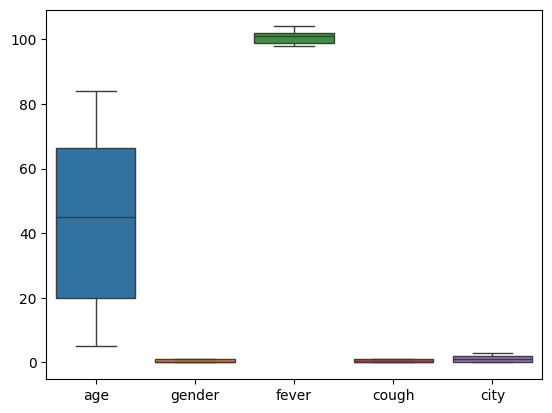

In [86]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(X)
plt.show()

In [87]:
df1=pd.read_csv("/content/newplacementdata.csv")

In [88]:
df1

,cgpa,placement_exam_marks,placed
0,7.19,26,1
1,7.46,38,1
2,7.54,40,1
3,6.42,8,1
4,7.23,17,0
...,...,...,...
995,8.87,44,1
996,9.12,65,1
997,4.89,34,0
998,8.62,46,1


In [89]:
a=df1.drop('placed',axis=1)
b=df1['placed']

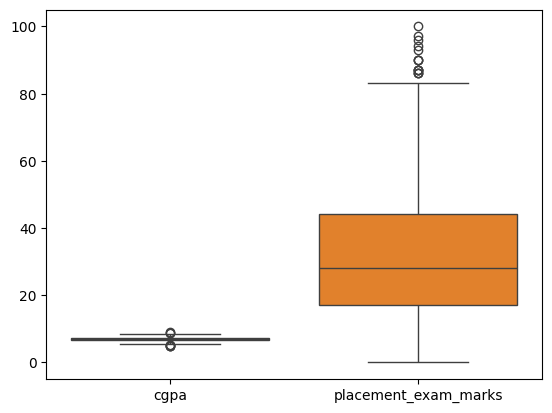

In [90]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(a)
plt.show()

In [93]:
def remove_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    return df[(df[col] >= lower) & (df[col] <= upper)]

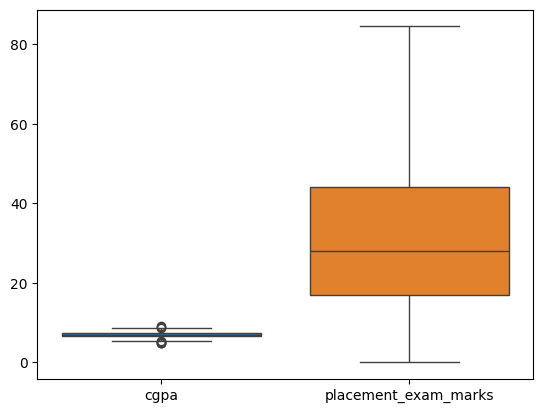

In [95]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(data=df1[['cgpa', 'placement_exam_marks']])
plt.show()

In [97]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5, 10]
}

grid = GridSearchCV(RandomForestClassifier(), param_grid, cv=5)

grid.fit(x_train, y_train)

print(grid.best_params_)

{'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 50}


In [100]:
from sklearn.metrics import accuracy_score

y_pred = rfc.predict(x_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.55
